# M04 — Focal Loss

**EEEM068 Applied Machine Learning — MaxViT-Tiny Optimisation Series (M04 of 8)**

Test whether focusing gradient signal on hard, low-confidence examples (rather than reweighting or resampling by class frequency) improves MaxViT's minority-class performance, compared directly against M01.

This notebook uses the same leakage-free patient-grouped split and the same P0 preprocessing
as the EfficientNet-B4 architecture comparison, so results stay comparable across
architectures. **The internal test set is not loaded or evaluated anywhere in this
notebook** — only validation results are produced here; the test set stays locked until a
final configuration is selected across M01-M08.

## 2. Hypothesis and change from previous experiment

Copied from **M01** (`M01_maxvit_baseline.ipynb`); everything except the loss function remains unchanged.

M04 replaces ordinary cross-entropy with focal loss using `gamma=2.0`. Sampling remains ordinary shuffling, and no class weights are applied.

**Question this experiment answers:** Does focal loss improve minority-class recognition over M01, and how does it compare to M02 (reweighting) and M03 (resampling)?

## 3. Imports

In [1]:
import json
import random
from pathlib import Path

import cv2
import timm
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import Dataset, DataLoader
from torch.optim.lr_scheduler import LinearLR, CosineAnnealingLR, SequentialLR

from torchvision import transforms

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    cohen_kappa_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)

print("Imports OK.")

Imports OK.


## 4. Experiment configuration

This section runs immediately after imports and before reproducibility/paths, because
`SEED` is defined here and the reproducibility cell (Section 5) depends on it — running
`set_seed()` before `SEED` exists would raise a `NameError`. `RUN_NAME` and `EXPERIMENT_ID`
are also defined only here, not repeated in the paths cell, so the experiment identifiers can
be updated in one configuration cell when creating the next notebook.

In [2]:
EXPERIMENT_ID = "M04"
RUN_NAME = "M04_focal_loss"

MODEL_NAME = "maxvit_tiny_tf_224.in1k"
IMAGE_SIZE = 224
NUM_CLASSES = 5
CLASS_NAMES = ["No DR", "Mild", "Moderate", "Severe", "Proliferative DR"]
SEED = 42

VIT_MEAN = (0.485, 0.456, 0.406)
VIT_STD = (0.229, 0.224, 0.225)

BATCH_SIZE = 32
LEARNING_RATE = 5e-05
WEIGHT_DECAY = 0.05

MAX_EPOCHS = 25
WARMUP_EPOCHS = 3
EARLY_STOPPING_PATIENCE = 7

LABEL_SMOOTHING = 0.0
GRAD_CLIP = 1.0
QWK_TOLERANCE = 1e-4
NUM_WORKERS = 4
TRAINING_MODE = "single_stage"
EXPERIMENT_TYPE = "loss_ablation"

FOCAL_GAMMA = 2.0

USE_CLASS_WEIGHTS = False
USE_WRS = False

print(f"Experiment : {EXPERIMENT_ID} / {RUN_NAME}")
print(f"LR={LEARNING_RATE}  WD={WEIGHT_DECAY}  BATCH={BATCH_SIZE}  "
      f"MAX_EPOCHS={MAX_EPOCHS}  PATIENCE={EARLY_STOPPING_PATIENCE}")

Experiment : M04 / M04_focal_loss
LR=5e-05  WD=0.05  BATCH=32  MAX_EPOCHS=25  PATIENCE=7


## 5. Reproducibility and device

Full seeding across Python/NumPy/PyTorch/CUDA, a seeded per-worker `DataLoader` RNG, and a
hard failure if no CUDA GPU is available. This must run after Section 4, since `set_seed()`
takes `SEED` as its default argument.

In [3]:
def set_seed(seed: int = SEED) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


def seed_worker(worker_id: int) -> None:
    worker_seed = torch.initial_seed() % (2**32)
    np.random.seed(worker_seed)
    random.seed(worker_seed)


set_seed()

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", device)

if device.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))

if device.type != "cuda":
    raise RuntimeError(
        "CUDA GPU is not available. Do not start this training run on CPU."
    )

Device: cuda
GPU: NVIDIA RTX A4000


## 6. Paths and output directories

Points at the same `configs/splits/` manifests used by the EfficientNet notebooks. This
notebook's own logs, checkpoints and figures are written to a run-specific subfolder (named
from `RUN_NAME`, defined in Section 4) so no other M01-M08 notebook's outputs are ever
overwritten.

In [4]:
PROJECT_ROOT = Path(
    "/scratch/New AML/EEEM068-LSA-Diabetic-Retinopathy"
)

SPLITS_DIR = PROJECT_ROOT / "configs" / "splits"

TRAIN_CSV = SPLITS_DIR / "train_split.csv"
VAL_CSV = SPLITS_DIR / "val_split.csv"
# The internal test split is intentionally not loaded anywhere in this
# notebook. It stays locked until a final MaxViT configuration is selected
# across M01-M08.

RUN_LOG_DIR = PROJECT_ROOT / "logs" / "maxvit_tiny" / RUN_NAME
CHECKPOINT_DIR = PROJECT_ROOT / "checkpoints" / "maxvit_tiny" / RUN_NAME
FIGURE_DIR = PROJECT_ROOT / "results" / "figures" / "maxvit_tiny" / RUN_NAME

for directory in [RUN_LOG_DIR, CHECKPOINT_DIR, FIGURE_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

BEST_CHECKPOINT_PATH = CHECKPOINT_DIR / "best.pt"


print(f"Run          : maxvit_tiny/{RUN_NAME}")
print(f"Logs         -> {RUN_LOG_DIR}")
print(f"Checkpoints  -> {CHECKPOINT_DIR}")
print(f"Figures      -> {FIGURE_DIR}")

Run          : maxvit_tiny/M04_focal_loss
Logs         -> /scratch/New AML/EEEM068-LSA-Diabetic-Retinopathy/logs/maxvit_tiny/M04_focal_loss
Checkpoints  -> /scratch/New AML/EEEM068-LSA-Diabetic-Retinopathy/checkpoints/maxvit_tiny/M04_focal_loss
Figures      -> /scratch/New AML/EEEM068-LSA-Diabetic-Retinopathy/results/figures/maxvit_tiny/M04_focal_loss


## 7. Load patient-grouped CSV files

Only `train_split.csv` and `val_split.csv` are loaded — the internal test split is
intentionally absent from this notebook entirely.

In [5]:
train_df = pd.read_csv(TRAIN_CSV)
val_df = pd.read_csv(VAL_CSV)

required_columns = {"image", "level", "patient_id", "eye", "filepath"}

for split_name, frame in [("train", train_df), ("validation", val_df)]:
    missing_columns = required_columns - set(frame.columns)
    if missing_columns:
        raise ValueError(
            f"{split_name} is missing columns: {sorted(missing_columns)}"
        )

    missing_files = frame.loc[
        ~frame["filepath"].map(lambda path: Path(path).exists())
    ]
    if len(missing_files) > 0:
        raise FileNotFoundError(
            f"{split_name} contains {len(missing_files):,} missing image files."
        )

print(f"Train      : {len(train_df):,}")
print(f"Validation : {len(val_df):,}")

Train      : 24,586
Validation : 5,270


## 8. Verify zero patient overlap

In [6]:
train_patients = set(train_df["patient_id"])
val_patients = set(val_df["patient_id"])

assert train_patients.isdisjoint(val_patients), (
    "Patient overlap detected between train and validation splits."
)

print(f"Train patients      : {len(train_patients):,}")
print(f"Validation patients : {len(val_patients):,}")
print("Patient overlap check: PASSED (zero overlap)")

Train patients      : 12,293
Validation patients : 2,635
Patient overlap check: PASSED (zero overlap)


## 9. Dataset class and transformations

`DRDataset` applies P0 preprocessing on the fly and returns `(image, label, index)`, so
predictions can be matched back to source rows later. Uses **no stochastic augmentation at all**: training and validation share the identical deterministic pipeline (resize + normalise only). This keeps M01-M04 a clean, uncontaminated comparison of loss/sampling strategy alone — augmentation is introduced separately, and only once, starting in M05. The evaluation transform is
a plain resize + normalise with no augmentation.

In [7]:
def _load_rgb(path: str) -> np.ndarray:
    """Load an image file and return it as an RGB uint8 array."""
    img_bgr = cv2.imread(str(path))
    if img_bgr is None:
        raise ValueError(f"Cannot decode image: {path}")
    return cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)


def _crop_black_borders(img: np.ndarray, threshold: int = 10) -> np.ndarray:
    """Crop the uninformative black padding around the retinal disc."""
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    _, mask = cv2.threshold(gray, threshold, 255, cv2.THRESH_BINARY)
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (25, 25))
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not contours:
        return img
    x, y, w, h = cv2.boundingRect(max(contours, key=cv2.contourArea))
    margin = int(min(w, h) * 0.02)
    x, y = max(0, x - margin), max(0, y - margin)
    w = min(img.shape[1] - x, w + 2 * margin)
    h = min(img.shape[0] - y, h + 2 * margin)
    return img[y:y + h, x:x + w]


def _pad_square(img: np.ndarray) -> np.ndarray:
    """Pad an image onto a centred square canvas (no resizing yet)."""
    h, w = img.shape[:2]
    side = max(h, w)
    canvas = np.zeros((side, side, 3), dtype=img.dtype)
    y = (side - h) // 2
    x = (side - w) // 2
    canvas[y:y + h, x:x + w] = img
    return canvas


def preprocess_p0(image_path: str, output_size: int = IMAGE_SIZE) -> np.ndarray:
    """P0: crop black borders, pad to square, resize. Same pipeline used for
    the EfficientNet-B4 architecture comparison, kept identical here so
    architecture comparisons are not confounded by preprocessing differences."""
    img = _load_rgb(image_path)
    img = _crop_black_borders(img)
    img = _pad_square(img)
    return cv2.resize(img, (output_size, output_size), interpolation=cv2.INTER_AREA)


print(f"P0 preprocessing ready. Output size: {IMAGE_SIZE}x{IMAGE_SIZE}, RGB, uint8.")

P0 preprocessing ready. Output size: 224x224, RGB, uint8.


In [8]:
class DRDataset(Dataset):
    def __init__(self, dataframe: pd.DataFrame, transform=None):
        self.df = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self) -> int:
        return len(self.df)

    def __getitem__(self, index: int):
        row = self.df.iloc[index]

        image = preprocess_p0(row["filepath"])
        image = Image.fromarray(image)

        label = int(row["level"])

        if self.transform is not None:
            image = self.transform(image)

        return image, label, index

In [9]:
# No stochastic augmentation anywhere in this notebook: train and eval use the
# identical deterministic pipeline (resize + normalise only). This keeps M01-M04
# a clean comparison of loss/sampling strategy alone, uncontaminated by any
# augmentation effect - augmentation is introduced separately, and only once, in M05.
train_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=VIT_MEAN, std=VIT_STD),
])

eval_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=VIT_MEAN, std=VIT_STD),
])

train_ds = DRDataset(train_df, transform=train_transform)
val_ds = DRDataset(val_df, transform=eval_transform)

AUGMENTATION_CONFIG = {
    "policy": "none",
    "resize": [IMAGE_SIZE, IMAGE_SIZE],
    "stochastic_augmentation": False,
}

print(f"train_ds: {len(train_ds):,} | val_ds: {len(val_ds):,}")

train_ds: 24,586 | val_ds: 5,270


## 10. DataLoaders

M04 uses ordinary random shuffling for training, with no `WeightedRandomSampler` and no class-weighted loss — this notebook isolates the loss function itself as the variable under test, comparable directly against the M01 baseline. The validation loader always uses `shuffle=False` and receives no
balancing or augmentation of any kind, regardless of what the training loader does.

In [10]:
train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    persistent_workers=NUM_WORKERS > 0,
    worker_init_fn=seed_worker,
)

val_loader = DataLoader(
    val_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    persistent_workers=NUM_WORKERS > 0,
    worker_init_fn=seed_worker,
)

print(f"Train batches: {len(train_loader)} | Val batches: {len(val_loader)}")

Train batches: 769 | Val batches: 165


## 11. Focal loss

Uses **focal loss** (`gamma=FOCAL_GAMMA`), which down-weights easy, already-confident predictions and concentrates gradient signal on hard examples — a different mechanism for handling imbalance than either reweighting (M02) or resampling (M03), tested here in isolation with no WRS and no class weights.

In [11]:
class FocalLoss(nn.Module):
    """Focal Loss (Lin et al., 2017): down-weights easy, already-confident examples
    and focuses gradient signal on hard ones. alpha=None -> uniform class priors;
    this is the sole balancing mechanism in M04, deliberately not combined with
    class-weighted loss or WRS, so the loss-strategy comparison against M01 is clean.
    """
    def __init__(self, gamma: float = FOCAL_GAMMA, label_smoothing: float = 0.0):
        super().__init__()
        self.gamma = gamma
        self.label_smoothing = label_smoothing

    def forward(self, logits: torch.Tensor, targets: torch.Tensor) -> torch.Tensor:
        ce = F.cross_entropy(
            logits, targets, reduction="none", label_smoothing=self.label_smoothing
        )
        pt = torch.exp(-ce)
        loss = (1 - pt) ** self.gamma * ce
        return loss.mean()


criterion = FocalLoss(gamma=FOCAL_GAMMA, label_smoothing=LABEL_SMOOTHING)
LOSS_FUNCTION_LABEL = "focal_loss"

print(f"Loss: FocalLoss(gamma={FOCAL_GAMMA})")
print("Use class weights:", USE_CLASS_WEIGHTS)
print("Use WRS:", USE_WRS)
print("Label smoothing:", LABEL_SMOOTHING)

Loss: FocalLoss(gamma=2.0)
Use class weights: False
Use WRS: False
Label smoothing: 0.0


## 12. MaxViT-Tiny model

The same pretrained `maxvit_tiny_tf_224.in1k` architecture used in M01 is
retained without modification. The classifier is configured for five diabetic
retinopathy grades through `timm.create_model(..., num_classes=5)`.

M04 uses single-stage full-model fine-tuning. Therefore, the model architecture
and training scope remain unchanged from M01, ensuring that focal loss is the
only component evaluated.

In [12]:
def build_model(pretrained: bool = True) -> nn.Module:
    """Build MaxViT-Tiny with timm's native num_classes head."""
    return timm.create_model(
        MODEL_NAME,
        pretrained=pretrained,
        num_classes=NUM_CLASSES,
    ).to(device)


model = build_model(pretrained=True)

total_parameters = sum(p.numel() for p in model.parameters())

print(f"Model: {MODEL_NAME}")
print(f"Total parameters: {total_parameters:,}")

Model: maxvit_tiny_tf_224.in1k
Total parameters: 30,406,093


## 13. Optimiser and scheduler

`AdamW` with a 3-epoch linear warm-up (`start_factor=0.1 -> 1.0`) followed by
`CosineAnnealingLR` for the remaining epochs, chained with `SequentialLR`. Warm-up matters
more for a pretrained model with attention layers than for a pure CNN: a large learning rate
applied immediately to a freshly-loaded backbone can quickly destroy useful pretrained
attention patterns before the model has had a chance to adapt gently — relevant here since
MaxViT's blocks include attention alongside its convolutional MBConv stages.

In [13]:
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
)

warmup_scheduler = LinearLR(
    optimizer, start_factor=0.1, end_factor=1.0, total_iters=WARMUP_EPOCHS,
)
cosine_scheduler = CosineAnnealingLR(
    optimizer, T_max=max(1, MAX_EPOCHS - WARMUP_EPOCHS),
)
scheduler = SequentialLR(
    optimizer,
    schedulers=[warmup_scheduler, cosine_scheduler],
    milestones=[WARMUP_EPOCHS],
)

SCHEDULER_CONFIG = {
    "name": "SequentialLR",
    "warmup_scheduler": "LinearLR",
    "warmup_start_factor": 0.1,
    "warmup_end_factor": 1.0,
    "warmup_epochs": WARMUP_EPOCHS,
    "main_scheduler": "CosineAnnealingLR",
}

print(f"Optimizer: AdamW(lr={LEARNING_RATE}, weight_decay={WEIGHT_DECAY})")
print(f"Scheduler: {WARMUP_EPOCHS}-epoch linear warm-up -> CosineAnnealingLR")

Optimizer: AdamW(lr=5e-05, weight_decay=0.05)
Scheduler: 3-epoch linear warm-up -> CosineAnnealingLR


## 14. Training and validation functions

`run_epoch()` disables gradient tracking entirely during evaluation, raises if a training
call is made without an optimizer, guards against an empty loader, and raises if QWK comes
back non-finite. This notebook is single-stage full fine-tuning, so there is no frozen-backbone phase and no BatchNorm-freeze subtlety to handle here — that mechanism is only introduced in the two-phase notebooks (M06 onward). `checkpoint_improved()` implements the agreed selection rule
exactly: **validation QWK primary** (must improve by more than `QWK_TOLERANCE`),
**validation macro-F1 as tie-break** when QWK is within tolerance of the current best.

In [14]:
use_amp = device.type == "cuda"
scaler = torch.amp.GradScaler("cuda", enabled=use_amp)


def run_epoch(
    model: nn.Module,
    loader,
    optimizer=None,
    train_mode: bool = True,
    grad_clip: float = GRAD_CLIP,
):
    """Run one complete training or evaluation epoch.

    This notebook is single-stage full fine-tuning, so there is no frozen-backbone
    phase and therefore no BatchNorm-freeze subtlety to handle here (that only
    matters once part of the model is frozen with requires_grad=False, which does
    not happen in this notebook) - see the two-phase notebooks for the head_only
    variant of this function.
    """

    if train_mode and optimizer is None:
        raise ValueError("An optimizer must be supplied during training.")

    model.train() if train_mode else model.eval()

    total_loss = 0.0
    total_samples = 0
    all_labels, all_preds, all_probs, all_indices = [], [], [], []

    description = "train" if train_mode else "eval"

    for images, labels, indices in tqdm(loader, leave=False, desc=description):
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        if train_mode:
            optimizer.zero_grad(set_to_none=True)

        with torch.set_grad_enabled(train_mode):
            with torch.autocast(device_type=device.type, enabled=use_amp):
                logits = model(images)
                loss = criterion(logits, labels)

        if train_mode:
            scaler.scale(loss).backward()
            if grad_clip > 0:
                scaler.unscale_(optimizer)
                nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
            scaler.step(optimizer)
            scaler.update()

        probabilities = F.softmax(logits.detach(), dim=1)
        batch_size = labels.size(0)

        total_loss += loss.item() * batch_size
        total_samples += batch_size

        all_preds.extend(probabilities.argmax(dim=1).cpu().tolist())
        all_labels.extend(labels.detach().cpu().tolist())
        all_probs.extend(probabilities.cpu().tolist())
        all_indices.extend(indices.cpu().tolist())

    if total_samples == 0:
        raise RuntimeError("The DataLoader produced no samples.")

    epoch_qwk = cohen_kappa_score(all_labels, all_preds, weights="quadratic")
    if not np.isfinite(epoch_qwk):
        raise RuntimeError("QWK became NaN or infinity during the epoch.")

    return {
        "loss": total_loss / total_samples,
        "accuracy": accuracy_score(all_labels, all_preds),
        "balanced_accuracy": balanced_accuracy_score(all_labels, all_preds),
        "macro_f1": f1_score(all_labels, all_preds, average="macro", zero_division=0),
        "qwk": epoch_qwk,
        "labels": all_labels,
        "preds": all_preds,
        "probs": all_probs,
        "indices": all_indices,
    }


def checkpoint_improved(
    val_qwk: float,
    val_macro_f1: float,
    best_qwk: float,
    best_macro_f1: float,
    tolerance: float = QWK_TOLERANCE,
) -> bool:
    """Validation QWK primary, validation macro-F1 tie-break."""
    if val_qwk > best_qwk + tolerance:
        return True
    if abs(val_qwk - best_qwk) <= tolerance and val_macro_f1 > best_macro_f1:
        return True
    return False

## 15. Early-stopping training loop

Checkpoint selection uses `checkpoint_improved()` (Section 14) on every epoch: validation QWK
primary, validation macro-F1 tie-break. `training_history.csv` is re-saved after every epoch,
not just at the end, so an interrupted run never loses its log.

In [15]:
history = []
best_qwk = -1.0
best_macro_f1 = -1.0
patience_left = EARLY_STOPPING_PATIENCE

print("=" * 60)
print(f"  {RUN_NAME}")
print("=" * 60)
print(f"{'Epoch':<8} {'Tr Loss':>10} {'Tr QWK':>8} {'Val Loss':>10} {'Val QWK':>8} {'Val F1':>8}")
print("-" * 60)

for epoch in range(1, MAX_EPOCHS + 1):
    lr_used = optimizer.param_groups[0]["lr"]

    train_metrics = run_epoch(model, train_loader, optimizer=optimizer, train_mode=True)
    val_metrics = run_epoch(model, val_loader, train_mode=False)
    scheduler.step()

    epoch_record = {
        "epoch": epoch,
        "train_loss": train_metrics["loss"],
        "val_loss": val_metrics["loss"],
        "train_accuracy": train_metrics["accuracy"],
        "val_accuracy": val_metrics["accuracy"],
        "train_balanced_accuracy": train_metrics["balanced_accuracy"],
        "val_balanced_accuracy": val_metrics["balanced_accuracy"],
        "train_macro_f1": train_metrics["macro_f1"],
        "val_macro_f1": val_metrics["macro_f1"],
        "train_qwk": train_metrics["qwk"],
        "val_qwk": val_metrics["qwk"],
        "learning_rate": lr_used,
    }
    history.append(epoch_record)
    pd.DataFrame(history).to_csv(RUN_LOG_DIR / "training_history.csv", index=False)

    marker = ""
    if checkpoint_improved(val_metrics["qwk"], val_metrics["macro_f1"], best_qwk, best_macro_f1):
        best_qwk = val_metrics["qwk"]
        best_macro_f1 = val_metrics["macro_f1"]
        patience_left = EARLY_STOPPING_PATIENCE
        torch.save(
            {
                "epoch": epoch,
                "model_state": model.state_dict(),
                "val_loss": val_metrics["loss"],
                "val_accuracy": val_metrics["accuracy"],
                "val_balanced_accuracy": val_metrics["balanced_accuracy"],
                "val_macro_f1": val_metrics["macro_f1"],
                "val_qwk": val_metrics["qwk"],
            },
            BEST_CHECKPOINT_PATH,
        )
        marker = "  [best]"
    else:
        patience_left -= 1

    print(
        f"{epoch:<8} {train_metrics['loss']:>10.4f} {train_metrics['qwk']:>8.4f} "
        f"{val_metrics['loss']:>10.4f} {val_metrics['qwk']:>8.4f} {val_metrics['macro_f1']:>8.4f}"
        f"{marker}"
    )

    if patience_left <= 0:
        print(f"Early stopping at epoch {epoch}.")
        break

print(f"\nBest val QWK = {best_qwk:.4f} (macro-F1 = {best_macro_f1:.4f}) -> {BEST_CHECKPOINT_PATH.name}")

  M04_focal_loss
Epoch       Tr Loss   Tr QWK   Val Loss  Val QWK   Val F1
------------------------------------------------------------


train:   0%|          | 0/769 [00:00<?, ?it/s]

eval:   0%|          | 0/165 [00:00<?, ?it/s]

1            0.4349   0.1330     0.3573   0.4025   0.2385  [best]


train:   0%|          | 0/769 [00:00<?, ?it/s]

...

eval:   0%|          | 0/165 [00:00<?, ?it/s]

10           0.0117   0.9863     0.7641   0.7333   0.5121


train:   0%|          | 0/769 [00:00<?, ?it/s]

eval:   0%|          | 0/165 [00:00<?, ?it/s]

11           0.0100   0.9907     0.8693   0.7290   0.5166
Early stopping at epoch 11.

Best val QWK = 0.7335 (macro-F1 = 0.5074) -> best.pt


## 16. Training curves

Train/validation loss and QWK across every epoch actually run. 

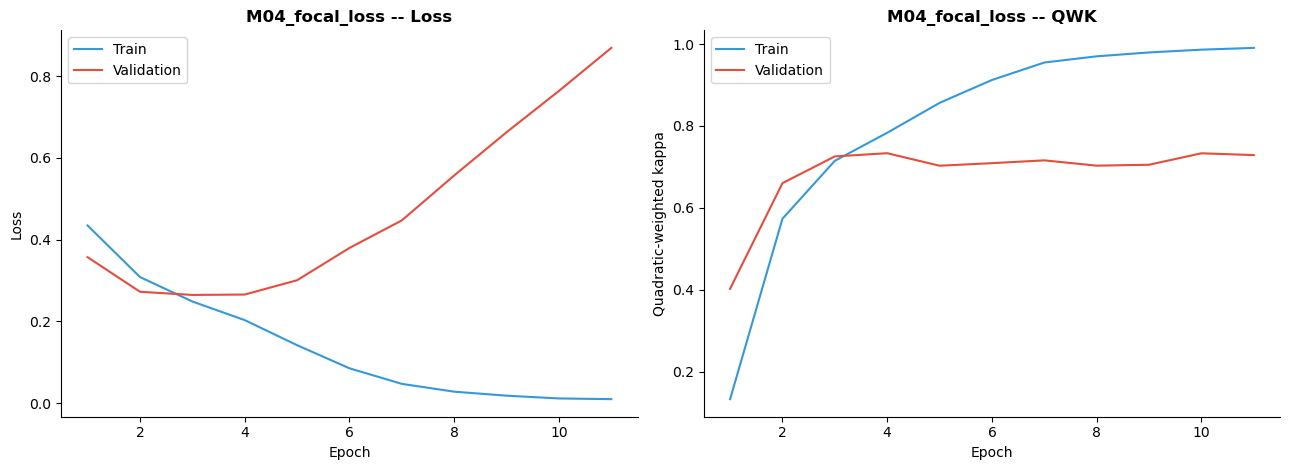

Saved -> /scratch/New AML/EEEM068-LSA-Diabetic-Retinopathy/results/figures/maxvit_tiny/M04_focal_loss/training_curves.png


In [16]:
history_df = pd.DataFrame(history)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))

axes[0].plot(history_df["epoch"], history_df["train_loss"], label="Train", color="#3498DB")
axes[0].plot(history_df["epoch"], history_df["val_loss"], label="Validation", color="#E74C3C")

axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss")
axes[0].set_title(f"{RUN_NAME} -- Loss", fontweight="bold")
axes[0].legend(); axes[0].spines[["top", "right"]].set_visible(False)

axes[1].plot(history_df["epoch"], history_df["train_qwk"], label="Train", color="#3498DB")
axes[1].plot(history_df["epoch"], history_df["val_qwk"], label="Validation", color="#E74C3C")

axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Quadratic-weighted kappa")
axes[1].set_title(f"{RUN_NAME} -- QWK", fontweight="bold")
axes[1].legend(); axes[1].spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.savefig(FIGURE_DIR / "training_curves.png", dpi=140, bbox_inches="tight")
plt.show()
print(f"Saved -> {FIGURE_DIR / 'training_curves.png'}")

## 17. Validation metrics and confusion matrix

The best checkpoint (by validation QWK, macro-F1 tie-break) is reloaded fresh and re-evaluated
on `val_loader` — **not the internal test set** — to get the metrics this notebook actually
reports: QWK, accuracy, balanced accuracy, macro-F1, macro precision/recall, and the full
per-class classification report, plus raw-count and row-normalised confusion matrices.

In [17]:
best_checkpoint = torch.load(BEST_CHECKPOINT_PATH, map_location=device, weights_only=False)

eval_model = build_model(pretrained=False)
eval_model.load_state_dict(best_checkpoint["model_state"])

print(f"Loaded: {BEST_CHECKPOINT_PATH.name}")
print(f"epoch={best_checkpoint['epoch']}  val_qwk={best_checkpoint['val_qwk']:.4f}  "
      f"val_macro_f1={best_checkpoint['val_macro_f1']:.4f}")

final_val_metrics = run_epoch(eval_model, val_loader, train_mode=False)

val_macro_precision = precision_score(
    final_val_metrics["labels"], final_val_metrics["preds"],
    average="macro", zero_division=0,
)
val_macro_recall = recall_score(
    final_val_metrics["labels"], final_val_metrics["preds"],
    average="macro", zero_division=0,
)

print()
print("=" * 60)
print(f"  {RUN_NAME} -- VALIDATION RESULTS (best checkpoint)")
print("=" * 60)
print(f"  Val QWK               : {final_val_metrics['qwk']:.4f}")
print(f"  Val accuracy           : {final_val_metrics['accuracy']:.4f}")
print(f"  Val balanced accuracy  : {final_val_metrics['balanced_accuracy']:.4f}")
print(f"  Val macro F1           : {final_val_metrics['macro_f1']:.4f}")
print(f"  Val macro precision    : {val_macro_precision:.4f}")
print(f"  Val macro recall       : {val_macro_recall:.4f}")
print()
print(classification_report(
    final_val_metrics["labels"], final_val_metrics["preds"],
    labels=list(range(NUM_CLASSES)), target_names=CLASS_NAMES,
    digits=3, zero_division=0,
))

Loaded: best.pt
epoch=4  val_qwk=0.7335  val_macro_f1=0.5074


eval:   0%|          | 0/165 [00:00<?, ?it/s]


  M04_focal_loss -- VALIDATION RESULTS (best checkpoint)
  Val QWK               : 0.7335
  Val accuracy           : 0.8046
  Val balanced accuracy  : 0.5256
  Val macro F1           : 0.5074
  Val macro precision    : 0.5952
  Val macro recall       : 0.5256

                  precision    recall  f1-score   support

           No DR      0.869     0.947     0.906      3873
            Mild      0.500     0.011     0.021       368
        Moderate      0.585     0.552     0.568       800
          Severe      0.351     0.559     0.432       127
Proliferative DR      0.671     0.559     0.610       102

        accuracy                          0.805      5270
       macro avg      0.595     0.526     0.507      5270
    weighted avg      0.784     0.805     0.776      5270



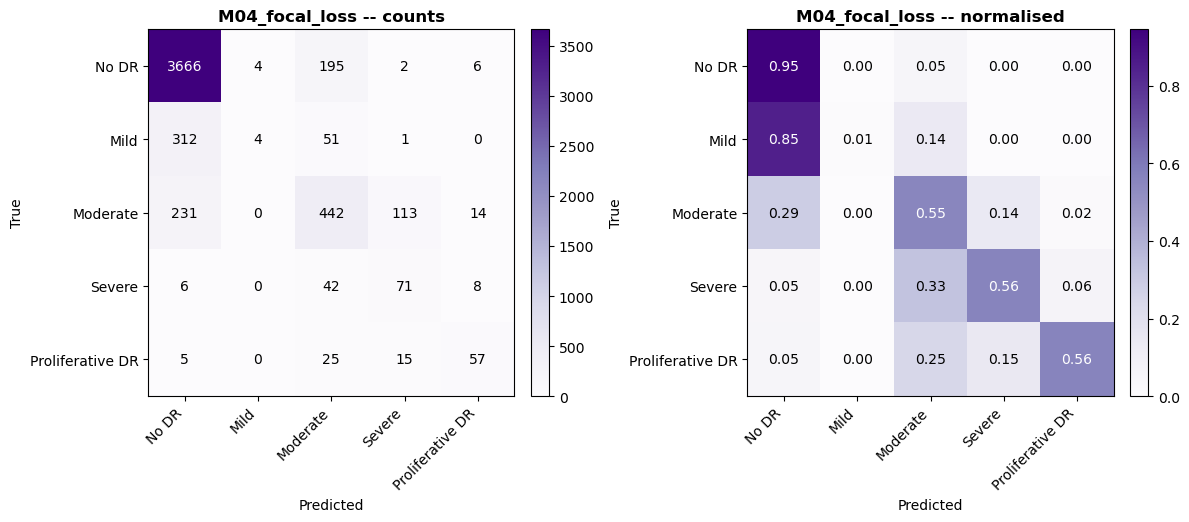

Saved -> /scratch/New AML/EEEM068-LSA-Diabetic-Retinopathy/results/figures/maxvit_tiny/M04_focal_loss/confusion_matrix.png


In [18]:
per_class_precision = precision_score(
    final_val_metrics["labels"], final_val_metrics["preds"],
    average=None, labels=list(range(NUM_CLASSES)), zero_division=0,
)
per_class_recall = recall_score(
    final_val_metrics["labels"], final_val_metrics["preds"],
    average=None, labels=list(range(NUM_CLASSES)), zero_division=0,
)
per_class_f1 = f1_score(
    final_val_metrics["labels"], final_val_metrics["preds"],
    average=None, labels=list(range(NUM_CLASSES)), zero_division=0,
)

cm_counts = confusion_matrix(final_val_metrics["labels"], final_val_metrics["preds"])
cm_normalised = cm_counts.astype(float) / cm_counts.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(12, 5.2))
for ax, data, fmt, title in [
    (axes[0], cm_counts, "d", f"{RUN_NAME} -- counts"),
    (axes[1], cm_normalised, ".2f", f"{RUN_NAME} -- normalised"),
]:
    im = ax.imshow(data, interpolation="nearest", cmap="Purples")
    ax.set_xticks(range(NUM_CLASSES)); ax.set_yticks(range(NUM_CLASSES))
    ax.set_xticklabels(CLASS_NAMES, rotation=45, ha="right")
    ax.set_yticklabels(CLASS_NAMES)
    ax.set_xlabel("Predicted"); ax.set_ylabel("True")
    ax.set_title(title, fontweight="bold")
    thresh = data.max() / 2.0
    for i in range(NUM_CLASSES):
        for j in range(NUM_CLASSES):
            ax.text(j, i, format(data[i, j], fmt), ha="center", va="center",
                     color="white" if data[i, j] > thresh else "black")
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.tight_layout()
plt.savefig(FIGURE_DIR / "confusion_matrix.png", dpi=140, bbox_inches="tight")
plt.show()
print(f"Saved -> {FIGURE_DIR / 'confusion_matrix.png'}")

## 18. Save logs and validation predictions

The notebook saves its configuration, selected validation metrics, complete
validation metrics, per-image validation predictions and training history.
The configuration also records focal-loss gamma and the exact change relative
to M01.

In [19]:
experiment_config = {
    "experiment_id": EXPERIMENT_ID,
    "run_name": RUN_NAME,
    "experiment_type": EXPERIMENT_TYPE,
    "focal_gamma": FOCAL_GAMMA,

    "model_name": MODEL_NAME,
    "seed": SEED,
    "image_size": IMAGE_SIZE,
    "num_classes": NUM_CLASSES,
    "class_names": CLASS_NAMES,
    "batch_size": BATCH_SIZE,
    "learning_rate": LEARNING_RATE,
    "weight_decay": WEIGHT_DECAY,
    "warmup_epochs": WARMUP_EPOCHS,
    "max_epochs": MAX_EPOCHS,
    "early_stopping_patience": EARLY_STOPPING_PATIENCE,
    "use_class_weights": USE_CLASS_WEIGHTS,
    "use_wrs": USE_WRS,
    "label_smoothing": LABEL_SMOOTHING,
    "grad_clip": GRAD_CLIP,
    "qwk_tolerance": QWK_TOLERANCE,
    "selection_metric": "validation_qwk",
    "selection_tiebreak": "validation_macro_f1",
    "training_mode": TRAINING_MODE,
    "preprocessing": "P0",
    "pretrained": True,
    "optimizer": "AdamW",
    "loss_function": LOSS_FUNCTION_LABEL,
    "sampler": "shuffle",
    "scheduler": SCHEDULER_CONFIG,
    "normalisation_mean": list(VIT_MEAN),
    "normalisation_std": list(VIT_STD),
    "training_augmentation": AUGMENTATION_CONFIG,
    "train_class_counts": {
        str(int(label)): int(count)
        for label, count in train_df["level"].value_counts().sort_index().items()
    },
    "total_parameters": total_parameters,
    "train_size": len(train_df),
    "val_size": len(val_df),
    "num_workers": NUM_WORKERS,
    "mixed_precision": use_amp,
    "device": torch.cuda.get_device_name(0),
    "torch_version": torch.__version__,
    "timm_version": timm.__version__,
    "train_csv": str(TRAIN_CSV),
    "val_csv": str(VAL_CSV),
}



experiment_config["change_from_m01"] = {
    "parameter": "loss_function",
    "m01_value": "CrossEntropyLoss",
    "m04_value": LOSS_FUNCTION_LABEL,
}

with open(RUN_LOG_DIR / "config.json", "w") as f:
    json.dump(experiment_config, f, indent=2)

best_metrics = {
    "epoch": best_checkpoint["epoch"],
    "val_loss": best_checkpoint["val_loss"],
    "val_accuracy": best_checkpoint["val_accuracy"],
    "val_balanced_accuracy": best_checkpoint["val_balanced_accuracy"],
    "val_macro_f1": best_checkpoint["val_macro_f1"],
    "val_qwk": best_checkpoint["val_qwk"],
}
with open(RUN_LOG_DIR / "best_metrics.json", "w") as f:
    json.dump(best_metrics, f, indent=2)

validation_metrics = {
    "qwk": final_val_metrics["qwk"],
    "accuracy": final_val_metrics["accuracy"],
    "balanced_accuracy": final_val_metrics["balanced_accuracy"],
    "macro_f1": final_val_metrics["macro_f1"],
    "macro_precision": val_macro_precision,
    "macro_recall": val_macro_recall,
    "per_class_precision": per_class_precision.tolist(),
    "per_class_recall": per_class_recall.tolist(),
    "per_class_f1": per_class_f1.tolist(),
}

with open(RUN_LOG_DIR / "validation_metrics.json", "w") as f:
    json.dump(validation_metrics, f, indent=2)

pred_rows = val_df.iloc[final_val_metrics["indices"]].reset_index(drop=True).copy()
pred_rows["true_label"] = final_val_metrics["labels"]
pred_rows["predicted_label"] = final_val_metrics["preds"]
probs_array = np.array(final_val_metrics["probs"])
for grade in range(NUM_CLASSES):
    pred_rows[f"prob_grade_{grade}"] = probs_array[:, grade]
pred_rows["correct"] = pred_rows["true_label"] == pred_rows["predicted_label"]

prediction_columns = [
    "image", "patient_id", "eye", "true_label", "predicted_label",
    "prob_grade_0", "prob_grade_1", "prob_grade_2", "prob_grade_3", "prob_grade_4",
    "correct",
]
pred_rows[prediction_columns].to_csv(RUN_LOG_DIR / "validation_predictions.csv", index=False)

print(f"Saved -> {RUN_LOG_DIR / 'config.json'}")
print(f"Saved -> {RUN_LOG_DIR / 'best_metrics.json'}")
print(f"Saved -> {RUN_LOG_DIR / 'validation_metrics.json'}")
print(f"Saved -> {RUN_LOG_DIR / 'validation_predictions.csv'}  ({len(pred_rows):,} rows)")
print()
print("training_history.csv was already saved incrementally during training.")

Saved -> /scratch/New AML/EEEM068-LSA-Diabetic-Retinopathy/logs/maxvit_tiny/M04_focal_loss/config.json
Saved -> /scratch/New AML/EEEM068-LSA-Diabetic-Retinopathy/logs/maxvit_tiny/M04_focal_loss/best_metrics.json
Saved -> /scratch/New AML/EEEM068-LSA-Diabetic-Retinopathy/logs/maxvit_tiny/M04_focal_loss/validation_metrics.json
Saved -> /scratch/New AML/EEEM068-LSA-Diabetic-Retinopathy/logs/maxvit_tiny/M04_focal_loss/validation_predictions.csv  (5,270 rows)

training_history.csv was already saved incrementally during training.


## 19. Experiment conclusion

M04 evaluated focal loss with gamma 2.0 while retaining the same MaxViT-Tiny
architecture, patient-grouped split, P0 preprocessing, optimiser, scheduler,
batch size and training protocol used in M01. No class weights,
WeightedRandomSampler or stochastic augmentation were used, so focal loss was
the only experimental change.

The best checkpoint occurred at epoch 4 and achieved a validation QWK of
0.7335, macro-F1 of 0.5074, accuracy of 0.8046 and balanced accuracy of
0.5256. Compared with M01, focal loss increased balanced accuracy from 0.5162
to 0.5256, but QWK decreased from 0.7425 to 0.7335, macro-F1 decreased from
0.5182 to 0.5074, and accuracy decreased from 0.8192 to 0.8046.

Focal loss changed class-level behaviour. Severe recall increased from 0.528
in M01 to 0.559, while Proliferative-DR recall increased from 0.510 to 0.559
and its F1 increased from 0.591 to 0.610. However, Moderate F1 decreased from
0.608 to 0.568 and Severe F1 decreased from 0.464 to 0.432. Mild DR remained
poorly recognised, with recall of 0.011 and F1 of 0.021.

Training QWK continued increasing to 0.9907 by epoch 11 while validation loss
rose from 0.2659 at the selected epoch to 0.8693. This divergence demonstrates
substantial overfitting after epoch 4, and confirms the importance of
validation-based checkpoint selection and early stopping.

Under the predefined validation-QWK-first selection rule, M04 does not replace
M01 as the current MaxViT reference configuration. Focal loss provided some
benefit for harder Severe and Proliferative-DR cases, but the improvement was
not broad enough to improve overall ordinal agreement.

M01 therefore remains the predecessor for M05, where safe retinal augmentation
will be evaluated as the next controlled component.

**Question answered:** Focal loss shifted attention toward selected difficult
grades and improved balanced accuracy, but it did not improve validation QWK or
macro-F1 over ordinary cross-entropy.